Tmax = 65.57028 degC at Tair=40, Vair=1.0, sgap=1
Tmin = 39.45075 degC at Tair=20, Vair=10.0, sgap=5
Air-cooling scan figure saved to: d:\Users\liu\Desktop\eBATS_scanned_final\out\C0004\Tmax_dT_Pfan_AC_BTMS_SCAN.png


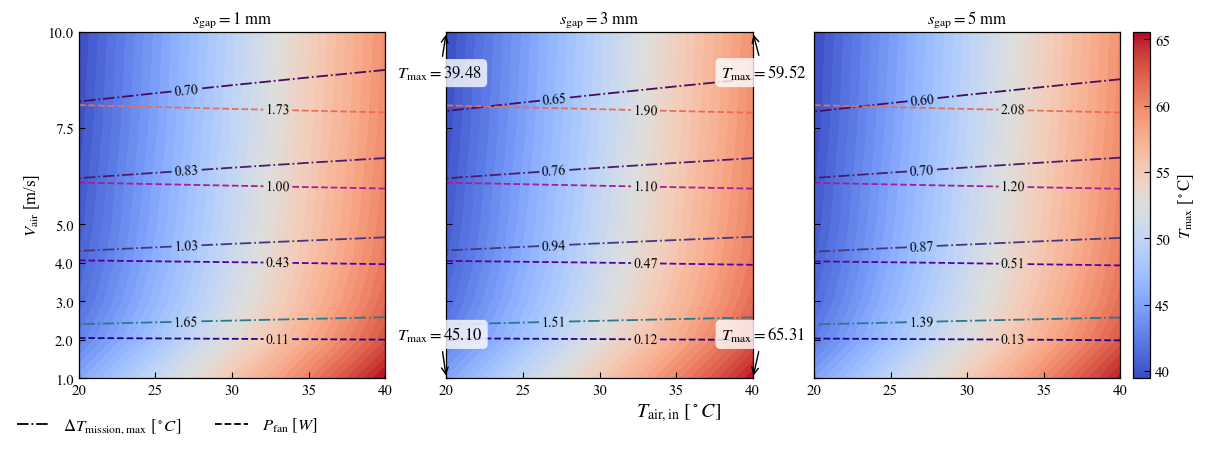

In [4]:
# ============================================================
# Air-cooled BTMS parametric scan
# Heat map: Tmax
# Contours: DeltaTmax and fan power
# ============================================================

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ============================================================
# 1. File path and data
# ============================================================

root_dir = os.path.abspath("../..")
CASE_ID = "C0004"

data_file = os.path.join(root_dir, "data", CASE_ID, "C0004R01_PARK25_AC_1D_SCAN.xlsx")
sheet_name = "Parameter scan"

data = pd.read_excel(data_file, sheet_name=sheet_name)

key_spacing = "s_gap_mm"
key_x = "T_air_in_C"
key_y = "V_air_m_s"
key_Tmax = "Tmax_mission_C"
key_dT = "DeltaT_mission_max_C"
key_Pfan = "P_pump"

SPACING_TO_PLOT = [1, 3, 5]

required_columns = [key_spacing, key_x, key_y, key_Tmax, key_dT, key_Pfan]
missing_columns = [c for c in required_columns if c not in data.columns]

if missing_columns:
    raise KeyError(f"Missing columns: {missing_columns}")

thermal_data = data[data[key_spacing].isin(SPACING_TO_PLOT)].copy()

# ============================================================
# 2. Figure style
# ============================================================

base_fontsize = 12

plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "font.size": base_fontsize,
    "axes.labelsize": base_fontsize,
    "axes.titlesize": base_fontsize,
    "xtick.labelsize": base_fontsize * 0.9,
    "ytick.labelsize": base_fontsize * 0.9,
    "axes.linewidth": 0.9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "axes.unicode_minus": False
})

def label_fmt(x):
    return f"{x:.2f}"

# ============================================================
# 3. Global Tmax range
# ============================================================

T_max = thermal_data[key_Tmax].max()
T_min = thermal_data[key_Tmax].min()

T_max_row = thermal_data.loc[thermal_data[key_Tmax].idxmax()]
T_min_row = thermal_data.loc[thermal_data[key_Tmax].idxmin()]

print(f"Tmax = {T_max:.5f} degC at Tair={T_max_row[key_x]}, Vair={T_max_row[key_y]}, sgap={T_max_row[key_spacing]}")
print(f"Tmin = {T_min:.5f} degC at Tair={T_min_row[key_x]}, Vair={T_min_row[key_y]}, sgap={T_min_row[key_spacing]}")

# ============================================================
# 4. Colormaps
# ============================================================

cmap_T = sns.color_palette("coolwarm", as_cmap=True)
cmap_dT = sns.color_palette("viridis", as_cmap=True)
cmap_Pfan = sns.color_palette("plasma", as_cmap=True)

# ============================================================
# 5. Contour positions
# ============================================================

V_TARGET_PFAN = np.array([2.0, 4.0, 6.0, 8.0])
V_TARGET_DT = np.array([2.5, 4.5, 6.5, 8.5])

def levels_from_target_y(Z, y_values, y_targets, decimals=2):
    profile = np.nanmean(Z, axis=1)
    y_targets = np.clip(np.asarray(y_targets, dtype=float), y_values.min(), y_values.max())
    levels = np.interp(y_targets, y_values, profile)
    return np.sort(np.unique(np.round(levels, decimals)))

# ============================================================
# 6. Plot
# ============================================================

fig, ax_dict = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)

for i, s_gap in enumerate(SPACING_TO_PLOT):

    ax = ax_dict[i]
    data_gap = thermal_data[np.isclose(thermal_data[key_spacing], s_gap)].copy()

    x_values = np.sort(data_gap[key_x].unique())
    y_values = np.sort(data_gap[key_y].unique())

    Z_values_T = data_gap.pivot(index=key_y, columns=key_x, values=key_Tmax).reindex(index=y_values, columns=x_values).values
    Z_values_dT = data_gap.pivot(index=key_y, columns=key_x, values=key_dT).reindex(index=y_values, columns=x_values).values
    Z_values_Pfan = data_gap.pivot(index=key_y, columns=key_x, values=key_Pfan).reindex(index=y_values, columns=x_values).values

    if np.isnan(Z_values_T).any() or np.isnan(Z_values_dT).any() or np.isnan(Z_values_Pfan).any():
        raise ValueError(f"Incomplete T_air-V_air grid for s_gap = {s_gap} mm")

    levels_dT = levels_from_target_y(Z_values_dT, y_values, V_TARGET_DT, decimals=2)
    levels_Pfan = levels_from_target_y(Z_values_Pfan, y_values, V_TARGET_PFAN, decimals=2)

    ax.contourf(x_values, y_values, Z_values_T, levels=50, cmap=cmap_T, vmin=T_min, vmax=T_max)

    cs_dT = ax.contour(x_values, y_values, Z_values_dT, levels=levels_dT, cmap=cmap_dT, vmin=Z_values_dT.min(), vmax=Z_values_dT.max(), linestyles="dashdot", linewidths=1.3)
    cs_Pfan = ax.contour(x_values, y_values, Z_values_Pfan, levels=levels_Pfan, cmap=cmap_Pfan, vmin=Z_values_Pfan.min(), vmax=Z_values_Pfan.max(), linestyles="dashed", linewidths=1.3)

    x_label_dT = x_values.min() + 0.35 * (x_values.max() - x_values.min())
    x_label_Pfan = x_values.min() + 0.65 * (x_values.max() - x_values.min())

    manual_dT = [(x_label_dT, y) for y in V_TARGET_DT]
    manual_Pfan = [(x_label_Pfan, y) for y in V_TARGET_PFAN]

    ax.clabel(cs_dT, inline=True, fontsize=10, fmt=label_fmt, colors="black", manual=manual_dT)
    ax.clabel(cs_Pfan, inline=True, fontsize=10, fmt=label_fmt, colors="black", manual=manual_Pfan)

    if s_gap == 3:

        T_top_left = Z_values_T[-1, 0]
        T_bottom_left = Z_values_T[0, 0]
        T_top_right = Z_values_T[-1, -1]
        T_bottom_right = Z_values_T[0, -1]

        annotation_style = dict(arrowprops=dict(arrowstyle="->", color="black", lw=1.0), fontsize=base_fontsize, bbox=dict(boxstyle="round,pad=0.3", edgecolor="none", facecolor="white", alpha=0.8))

        ax.annotate(fr"$T_\mathrm{{max}}={T_top_left:.2f}$", xy=(x_values[0], y_values[-1]), xytext=(x_values[0] - 3.2, y_values[-1] - 1.2), **annotation_style)
        ax.annotate(fr"$T_\mathrm{{max}}={T_bottom_left:.2f}$", xy=(x_values[0], y_values[0]), xytext=(x_values[0] - 3.2, y_values[0] + 1.0), **annotation_style)
        ax.annotate(fr"$T_\mathrm{{max}}={T_top_right:.2f}$", xy=(x_values[-1], y_values[-1]), xytext=(x_values[-1] - 2.1, y_values[-1] - 1.2), **annotation_style)
        ax.annotate(fr"$T_\mathrm{{max}}={T_bottom_right:.2f}$", xy=(x_values[-1], y_values[0]), xytext=(x_values[-1] - 2.1, y_values[0] + 1.0), **annotation_style)

    ax.set_title(rf"$s_\mathrm{{gap}}={s_gap:g}\ \mathrm{{mm}}$")
    ax.set_xticks(x_values)
    ax.set_yticks(y_values)

    if i == 0:
        ax.set_ylabel(r"$V_\mathrm{air}$ [m/s]")

# ============================================================
# 7. Shared labels and legend
# ============================================================

fig.supxlabel(r"$T_\mathrm{air,in}\ [^\circ C]$")

legend_elements = [
    Line2D([0], [0], color="black", lw=1.3, linestyle="dashdot", label=r"$\Delta T_\mathrm{mission,max}\ [^\circ C]$"),
    Line2D([0], [0], color="black", lw=1.3, linestyle="dashed", label=r"$P_\mathrm{fan}\ [W]$")
]

fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=base_fontsize, frameon=False, bbox_to_anchor=(0.18, -0.05))

# ============================================================
# 8. Shared Tmax colorbar
# ============================================================

sm = plt.cm.ScalarMappable(cmap=cmap_T, norm=Normalize(vmin=T_min, vmax=T_max))
sm.set_array([])

fig.colorbar(sm, ax=ax_dict, label=r"$T_{\max}$ [$^\circ$C]", pad=0.01)

# ============================================================
# 9. Save PNG only
# ============================================================

output_folder = os.path.join(root_dir, "out", CASE_ID)
os.makedirs(output_folder, exist_ok=True)

output_file = os.path.join(output_folder, "Tmax_dT_Pfan_AC_BTMS_SCAN.png")
fig.savefig(output_file, dpi=300, bbox_inches="tight")

print("Air-cooling scan figure saved to:", output_file)

plt.show()